In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:

# ---------------------------------------------
data_dir = "/content/drive/MyDrive/Garbage classification"

img_size = (128, 128)
batch_size = 32

In [ ]:
# ---------------------------------------------
# STEP 3: Data Generators with Augmentation
# ---------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("Classes:", train_generator.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
# ---------------------------------------------
# STEP 4: Build Deep CNN model (Model 2)
# ---------------------------------------------
model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,586,438 (17.50 MB)

 Trainable params: 4,585,478 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ---------------------------------------------
# STEP 5: Compile the model
# ---------------------------------------------
optimizer = Adam(learning_rate=0.0001)
model2.compile(optimizer=optimizer,
               loss='categorical_crossentropy',
               metrics=['accuracy'])


In [ ]:
# ---------------------------------------------
# STEP 6: Train the model
# ---------------------------------------------
history2 = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.3985 - loss: 2.2275 - val_accuracy: 0.0537 - val_loss: 2.0425
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.5434 - loss: 1.2226 - val_accuracy: 0.0815 - val_loss: 2.8098
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.5945 - loss: 1.1204 - val_accuracy: 0.0537 - val_loss: 2.9476
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.6352 - loss: 1.0445 - val_accuracy: 0.1948 - val_loss: 3.6410
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.6570 - loss: 0.9484 - val_accuracy: 0.1491 - val_loss: 3.1714
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.6581 - loss: 0.9468 - val_accuracy: 0.2485 - val_loss: 2.6594
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.6592 - loss: 0.9383 - val_accuracy: 0.3598 - val_loss: 2.0111
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.6758 - loss: 0.8763 - val_accuracy: 0.5050 - v

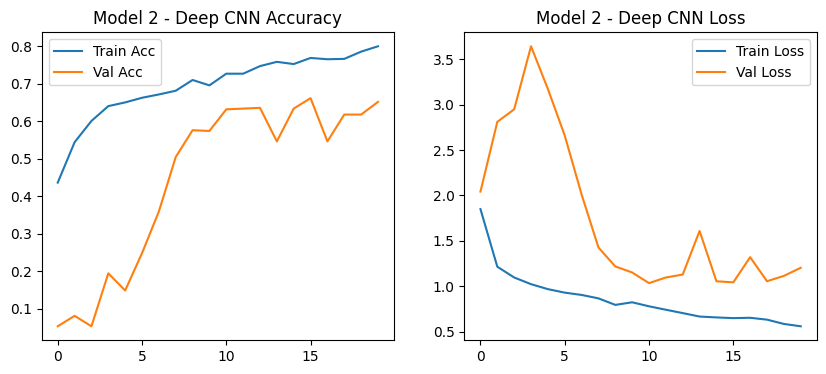

In [ ]:
# ---------------------------------------------
# STEP 7: Plot training results
# ---------------------------------------------
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='Val Acc')
plt.title('Model 2 - Deep CNN Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model 2 - Deep CNN Loss')
plt.legend()

plt.show()